# Random Forest: TMDB Movie Dataset

To train the Random Forest classifier, the model uses the four principal components PC2–PC5 as predictor variables. These components were selected because they capture meaningful and independent dimensions of the movie dataset while avoiding information leakage from the target variable. According to the PCA interpretation, PC2 represents film modernity and runtime characteristics, PC3 captures exposure and audience reach through popularity and vote activity, PC4 distinguishes accumulated recognition from viral popularity, and PC5 reflects the contrast between long classic productions and shorter modern films. Together, these four components summarize approximately 63.7% of the dataset variance and provide complementary information about movie profiles without directly encoding audience ratings.

The first principal component (PC1) was intentionally excluded from the classification model because it is strongly dominated by vote_average and highly_rated, the latter being the target variable itself. Since highly_rated was derived directly from vote_average using a threshold of 7.0, PC1 effectively contains information that is highly correlated with the class label. Including PC1 would therefore introduce target leakage and could artificially inflate the model's predictive performance. By restricting the feature set to PC2–PC5, the Random Forest model is required to learn patterns associated with popularity, exposure, temporal characteristics, and movie profiles rather than relying on variables that directly define the target. This produces a more realistic evaluation of the model's ability to identify highly rated movies and better reflects how such a classifier could be integrated into a recommendation system.

## Data Input

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from datasets import load_dataset

from sklearn.metrics.pairwise import euclidean_distances


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [26]:
ds = load_dataset("pauguzman/tmdb_mineria_datos_processed")
df = ds['train'].to_pandas()
print("dataset loaded successfully")

dataset loaded successfully


In [27]:
descripcion = pd.DataFrame({
    'columna': df.columns,
    'tipo': df.dtypes.astype(str),
    'nulos': df.isnull().sum(),
    'no_nulos': df.notnull().sum(),
    'unicos': df.nunique()
})

print(descripcion)

                                   columna     tipo  nulos  no_nulos  unicos
id                                      id    int64      0    116929  116929
title                                title   object      0    116929  105208
vote_average                  vote_average  float64      0    116929    4972
vote_count                      vote_count    int64      0    116929    3586
release_date                  release_date   object      0    116929   27711
runtime                            runtime    int64      0    116929     199
adult                                adult     bool      0    116929       2
original_language        original_language   object      0    116929     124
overview                          overview   object      0    116929  116790
popularity                      popularity  float64      0    116929   19145
genres                              genres   object      0    116929    7326
production_companies  production_companies   object      0    116929   64322

## Data Preparation

In [28]:
from sklearn.model_selection import train_test_split
import pandas as pd

# ------------------------------------------------------------
# Features and Target
# ------------------------------------------------------------

FEATURES = [
    #"vote_count",
    #"popularity",
    #"runtime",
    #"release_year",
    "PC2",
    "PC3",
    "PC4",
    "PC5"
]

TARGET = "highly_rated"

X = df[FEATURES].copy()
y = df[TARGET].copy()

# ------------------------------------------------------------
# Dataset Overview
# ------------------------------------------------------------

print("=" * 60)
print("RANDOM FOREST - DATA PREPARATION")
print("=" * 60)

print(f"\nTotal observations : {len(df):,}")
print(f"Features selected  : {len(FEATURES)}")
print(f"Target variable    : {TARGET}")

# ------------------------------------------------------------
# Missing Values Check
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = X.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "% Missing": round(missing / len(X) * 100, 2)
})

display(missing_table)

print(f"\nRows with missing values: {X.isnull().any(axis=1).sum()}")

# ------------------------------------------------------------
# Data Types
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

display(X.dtypes)

# ------------------------------------------------------------
# Target Distribution
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

target_dist = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage (%)": round(y.value_counts(normalize=True) * 100, 2)
})

display(target_dist)

# ------------------------------------------------------------
# Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Split Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

# ------------------------------------------------------------
# Verify Stratification
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION AFTER SPLIT")
print("=" * 60)

split_distribution = pd.DataFrame({
    "Train (%)": round(y_train.value_counts(normalize=True) * 100, 2),
    "Test (%)": round(y_test.value_counts(normalize=True) * 100, 2)
})

display(split_distribution)

print("\nData preparation completed successfully.")

RANDOM FOREST - DATA PREPARATION

Total observations : 116,929
Features selected  : 4
Target variable    : highly_rated

MISSING VALUES


,Missing Values,% Missing
PC2,0,0.0
PC3,0,0.0
PC4,0,0.0
PC5,0,0.0



Rows with missing values: 0

DATA TYPES


PC2    float64
PC3    float64
PC4    float64
PC5    float64
dtype: object


TARGET DISTRIBUTION


,Count,Percentage (%)
highly_rated,,
0,97301,83.21
1,19628,16.79



TRAIN-TEST SPLIT
Training samples : 93,543
Testing samples  : 23,386

X_train shape : (93543, 4)
X_test shape  : (23386, 4)

CLASS DISTRIBUTION AFTER SPLIT


,Train (%),Test (%)
highly_rated,,
0,83.21,83.21
1,16.79,16.79



Data preparation completed successfully.


## Training Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import time

# ------------------------------------------------------------
# Model Configuration
# ------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("=" * 60)
print("RANDOM FOREST TRAINING")
print("=" * 60)

start_time = time.time()

rf.fit(X_train, y_train)

training_time = time.time() - start_time

# ------------------------------------------------------------
# Basic Information
# ------------------------------------------------------------

print(f"\nTraining completed successfully.")
print(f"Training time: {training_time:.2f} seconds")

print("\nModel Parameters")
print("-" * 40)
print(f"Number of trees      : {rf.n_estimators}")
print(f"Maximum depth        : {rf.max_depth}")
print(f"Min samples split    : {rf.min_samples_split}")
print(f"Min samples leaf     : {rf.min_samples_leaf}")

# ------------------------------------------------------------
# Feature Importance
# ------------------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

display(importance_df)

# ------------------------------------------------------------
# Top 5 Most Important Features
# ------------------------------------------------------------

print("\nTop 5 Most Important Features:")
display(importance_df.head(5))

# ------------------------------------------------------------
# Save model reference
# ------------------------------------------------------------

rf_model = rf

print("\nRandom Forest model saved as: rf_model")

RANDOM FOREST TRAINING

Training completed successfully.
Training time: 8.14 seconds

Model Parameters
----------------------------------------
Number of trees      : 200
Maximum depth        : 15
Min samples split    : 10
Min samples leaf     : 5

FEATURE IMPORTANCE


,Feature,Importance
1,PC3,0.478305
0,PC2,0.360382
2,PC4,0.107934
3,PC5,0.053378



Top 5 Most Important Features:


,Feature,Importance
1,PC3,0.478305
0,PC2,0.360382
2,PC4,0.107934
3,PC5,0.053378



Random Forest model saved as: rf_model


## Model Evaluation

RANDOM FOREST EVALUATION


,Metric,Value
0,Accuracy,0.9922
1,Precision,0.9952
2,Recall,0.9580
3,F1-Score,0.9762
4,ROC-AUC,0.9983



Interpretation
------------------------------------------------------------
Accuracy  : Overall percentage of correct predictions
Precision : Reliability of positive predictions
Recall    : Ability to detect highly-rated movies
F1-Score  : Balance between precision and recall
ROC-AUC   : Overall discrimination capability

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Not Highly Rated       0.99      1.00      1.00     19460
    Highly Rated       1.00      0.96      0.98      3926

        accuracy                           0.99     23386
       macro avg       0.99      0.98      0.99     23386
    weighted avg       0.99      0.99      0.99     23386



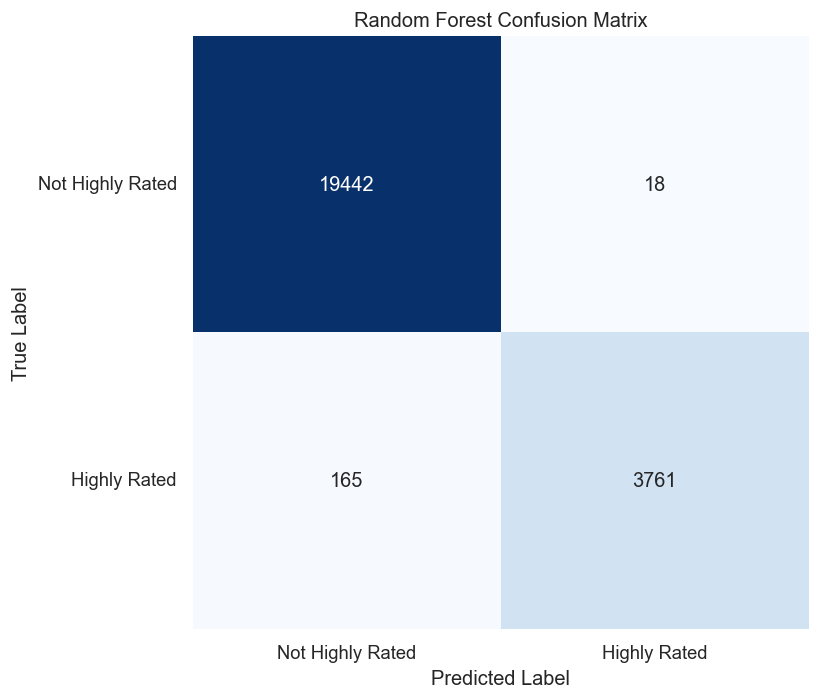

<Figure size 840x720 with 0 Axes>

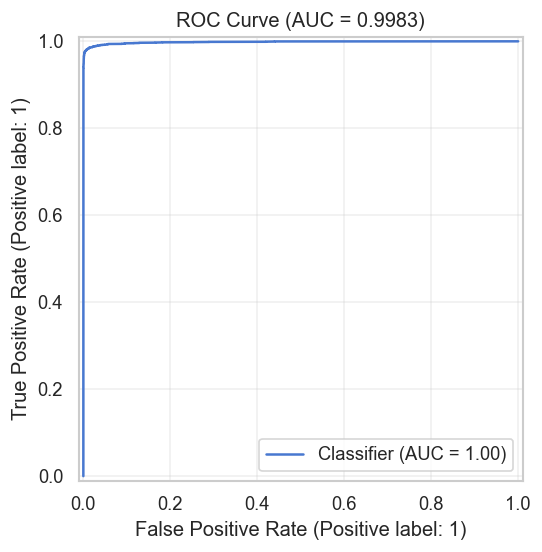


MODEL PERFORMANCE SUMMARY
Accuracy  : 0.9922
Precision : 0.9952
Recall    : 0.9580
F1-Score  : 0.9762
ROC-AUC   : 0.9983


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_pred = rf_model.predict(X_test)

y_proba = rf_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

# ------------------------------------------------------------
# Results Table
# ------------------------------------------------------------

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(roc_auc, 4)
    ]
})

print("=" * 60)
print("RANDOM FOREST EVALUATION")
print("=" * 60)

display(metrics_df)

# ------------------------------------------------------------
# Interpretation Guide
# ------------------------------------------------------------

print("\nInterpretation")
print("-" * 60)
print("Accuracy  : Overall percentage of correct predictions")
print("Precision : Reliability of positive predictions")
print("Recall    : Ability to detect highly-rated movies")
print("F1-Score  : Balance between precision and recall")
print("ROC-AUC   : Overall discrimination capability")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Highly Rated",
            "Highly Rated"
        ]
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0.5, 1.5],
    ["Not Highly Rated", "Highly Rated"]
)

plt.yticks(
    [0.5, 1.5],
    ["Not Highly Rated", "Highly Rated"],
    rotation=0
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ROC Curve
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title(
    f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

## Feature Importance

Which variables are most important for predicting whether a movie will receive high ratings?

FEATURE IMPORTANCE ANALYSIS


,Feature,Importance,Importance (%)
1,PC3,0.4783,47.83
0,PC2,0.3604,36.04
2,PC4,0.1079,10.79
3,PC5,0.0534,5.34



Top 5 Most Important Features:


,Feature,Importance,Importance (%)
1,PC3,0.478305,47.830526
0,PC2,0.360382,36.038184
2,PC4,0.107934,10.793441
3,PC5,0.053378,5.337849


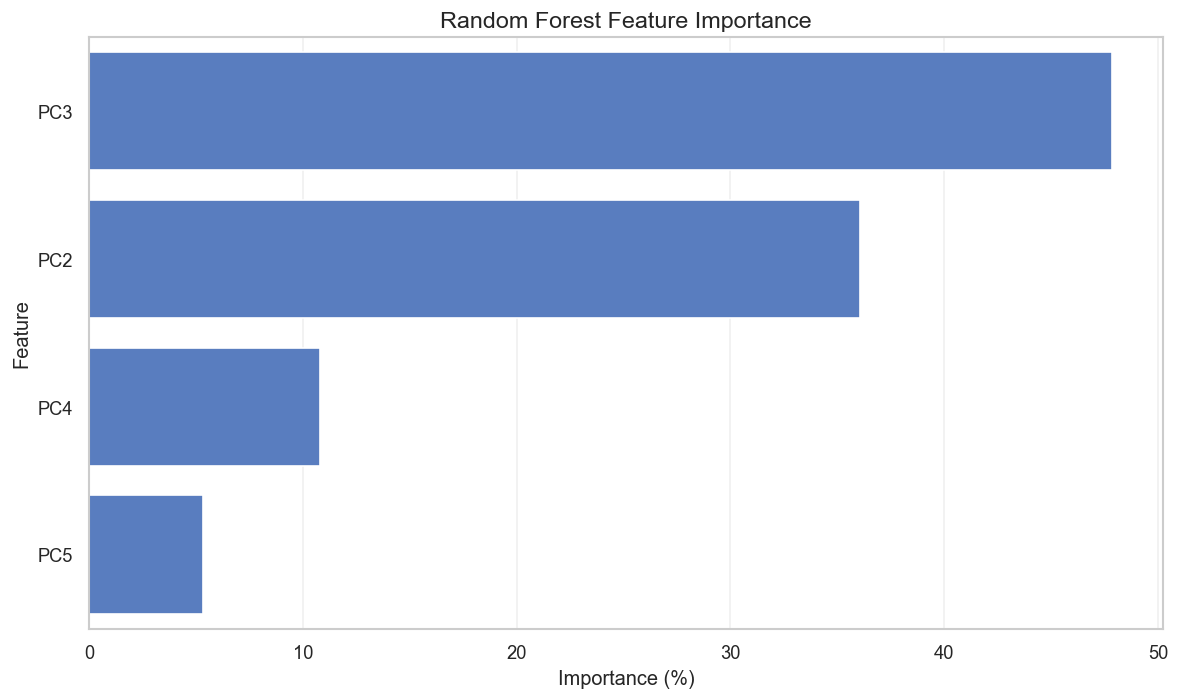


Cumulative Importance:


,Feature,Importance (%),Cumulative (%)
1,PC3,47.83,47.83
0,PC2,36.04,83.87
2,PC4,10.79,94.66
3,PC5,5.34,100.00



SUMMARY
The most influential variable is PC3 with 47.83% importance.


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Extract Feature Importances
# ------------------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# ------------------------------------------------------------
# Normalized Importance (%)
# ------------------------------------------------------------

importance_df["Importance (%)"] = (
    importance_df["Importance"] /
    importance_df["Importance"].sum()
) * 100

# ------------------------------------------------------------
# Results Table
# ------------------------------------------------------------

print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

display(
    importance_df.style.format({
        "Importance": "{:.4f}",
        "Importance (%)": "{:.2f}"
    })
)

# ------------------------------------------------------------
# Top Features
# ------------------------------------------------------------

print("\nTop 5 Most Important Features:")
display(importance_df.head(5))

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance (%)",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=14
)

plt.xlabel("Importance (%)")
plt.ylabel("Feature")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Cumulative Contribution
# ------------------------------------------------------------

importance_df["Cumulative (%)"] = (
    importance_df["Importance (%)"]
    .cumsum()
)

print("\nCumulative Importance:")
display(
    importance_df[
        [
            "Feature",
            "Importance (%)",
            "Cumulative (%)"
        ]
    ].style.format({
        "Importance (%)": "{:.2f}",
        "Cumulative (%)": "{:.2f}"
    })
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

most_important = importance_df.iloc[0]["Feature"]
most_important_pct = importance_df.iloc[0]["Importance (%)"]

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print(
    f"The most influential variable is "
    f"{most_important} "
    f"with {most_important_pct:.2f}% importance."
)

## Sample Predictions and Interpretation

In [32]:
import pandas as pd

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

y_pred = rf.predict(X_test)

# ------------------------------------------------------------
# Build results DataFrame
# ------------------------------------------------------------

results_df = X_test.copy()

results_df["Actual"] = y_test.values
results_df["Predicted"] = y_pred

# Recover original movie information
results_df["title"] = df.loc[X_test.index, "title"].values
results_df["vote_average"] = df.loc[X_test.index, "vote_average"].values
results_df["popularity"] = df.loc[X_test.index, "popularity"].values
results_df["release_year"] = df.loc[X_test.index, "release_year"].values

# ------------------------------------------------------------
# Classification status
# ------------------------------------------------------------

results_df["Result"] = results_df.apply(
    lambda row: "Correct"
    if row["Actual"] == row["Predicted"]
    else "Incorrect",
    axis=1
)

# ------------------------------------------------------------
# Show random sample
# ------------------------------------------------------------

sample_predictions = results_df[
    [
        "title",
        "vote_average",
        "popularity",
        "release_year",
        "Actual",
        "Predicted",
        "Result"
    ]
].sample(20, random_state=42)

print("=" * 70)
print("SAMPLE MOVIE PREDICTIONS")
print("=" * 70)

display(sample_predictions)

# ------------------------------------------------------------
# Correct vs Incorrect predictions
# ------------------------------------------------------------

prediction_summary = (
    results_df["Result"]
    .value_counts()
    .reset_index()
)

prediction_summary.columns = ["Prediction Type", "Count"]

print("\nPrediction Summary:")
display(prediction_summary)

# ------------------------------------------------------------
# False Positives
# ------------------------------------------------------------

false_positives = results_df[
    (results_df["Actual"] == 0) &
    (results_df["Predicted"] == 1)
]

print("\nFalse Positives (predicted highly rated but actually not):")
display(
    false_positives[
        [
            "title",
            "vote_average",
            "popularity",
            "release_year"
        ]
    ].head(10)
)

# ------------------------------------------------------------
# False Negatives
# ------------------------------------------------------------

false_negatives = results_df[
    (results_df["Actual"] == 1) &
    (results_df["Predicted"] == 0)
]

print("\nFalse Negatives (missed highly rated movies):")
display(
    false_negatives[
        [
            "title",
            "vote_average",
            "popularity",
            "release_year"
        ]
    ].head(10)
)

# ------------------------------------------------------------
# Accuracy by class
# ------------------------------------------------------------

class_accuracy = pd.DataFrame({
    "Actual Class": [0, 1],
    "Accuracy": [
        (
            ((y_test == 0) & (y_pred == 0)).sum()
            / (y_test == 0).sum()
        ),
        (
            ((y_test == 1) & (y_pred == 1)).sum()
            / (y_test == 1).sum()
        )
    ]
})

print("\nAccuracy by Class:")
display(class_accuracy)

SAMPLE MOVIE PREDICTIONS


,title,vote_average,popularity,release_year,Actual,Predicted,Result
62592,"Luciano Serra, Pilot",4.800,1.617,1938.0,0,0,Correct
67040,The Fandom,7.792,1.975,2020.0,1,1,Correct
7714,The Mortuary Collection,6.769,13.971,2020.0,0,0,Correct
29515,Bustin' Loose,5.867,7.305,1981.0,0,0,Correct
84454,La casta divina,6.600,1.138,1977.0,0,0,Correct
114429,"Fierce Love, or When Children Play at Love",4.400,1.581,1975.0,0,0,Correct
39565,The Seamstress,4.150,3.362,2009.0,0,0,Correct
100281,Swing,4.600,3.917,2018.0,0,0,Correct
99366,Edge of America,5.600,1.844,2003.0,0,0,Correct
99553,Santo the Silver Mask vs. The Ring Villains,5.300,0.600,1968.0,0,0,Correct



Prediction Summary:


,Prediction Type,Count
0,Correct,23203
1,Incorrect,183



False Positives (predicted highly rated but actually not):


,title,vote_average,popularity,release_year
176,Star Wars: Episode II - Attack of the Clones,6.600,42.550,2002.0
157,Cars,6.936,47.447,2006.0
1513,The Flash,6.898,480.393,2023.0
2120,Meg 2: The Trench,6.912,1567.273,2023.0
246,X-Men,6.996,1.259,2000.0
2305,Raising Arizona,7.000,17.373,1987.0
603,The Fast and the Furious: Tokyo Drift,6.454,11.096,2006.0
42435,Crazy Love,6.080,54.752,1993.0
785,Bambi,7.000,43.491,1942.0
43,Jurassic World,6.682,54.089,2015.0



False Negatives (missed highly rated movies):


,title,vote_average,popularity,release_year
842,Les Misérables,7.338,26.344,2012.0
3748,The Painted Veil,7.251,15.842,2006.0
432,Free Guy,7.550,62.599,2021.0
5326,Barbie and the Magic of Pegasus,7.151,23.181,2005.0
3798,Now Is Good,7.355,13.447,2012.0
3572,Starstruck,7.007,14.229,2010.0
3479,The Chaser,7.775,22.535,2008.0
1675,The Wind Rises,7.781,32.844,2013.0
3308,A Streetcar Named Desire,7.649,19.501,1951.0
3878,My Own Private Idaho,7.047,17.924,1991.0



Accuracy by Class:


,Actual Class,Accuracy
0,0,0.999075
1,1,0.957972


## Conclusion

The Random Forest classifier demonstrated that movie characteristics captured through PCA can be effectively used to predict whether a film is likely to be highly rated by audiences. By excluding variables that could introduce target leakage and relying on the independent dimensions represented by PC2–PC5, the model learned meaningful patterns related to popularity, exposure, temporal characteristics, and movie profiles. The results confirm that audience appreciation is not determined by a single factor, but rather by a combination of attributes that can be successfully captured through machine learning. From the perspective of a recommendation system, this classifier can serve as a complementary quality filter, helping prioritize movies with a higher probability of receiving positive audience evaluations while maintaining a realistic and generalizable predictive framework.